# Fourier Series & Harmonic Regression cho Phân tích Time Series



## Bối cảnh



Khi chúng ta muốn mô hình hóa seasonality (tính mùa vụ) trong time series của mình, chúng ta thường chuyển sang mô hình SARIMA. Điều này thêm các thành phần seasonality vào mô hình ARIMA bằng cách tìm autoregressors và moving-averages tại các chỉ số lag cụ thể nhất định. Ví dụ, dữ liệu hàng tháng với seasonality hàng năm sẽ fit autoregressors và moving averages ở bội số của 12.

Tuy nhiên, điều gì sẽ xảy ra nếu chúng ta có dữ liệu hàng ngày với seasonality hàng năm là 365.25 ngày? Hoặc thậm chí dữ liệu hàng tuần với seasonality là 52.14?

Thật không may, SARIMA không thể xử lý điều này vì nó không phải số nguyên và cũng gặp khó khăn về mặt tính toán do bộ nhớ cần thiết để tìm patterns (mẫu) trong 365 điểm dữ liệu mỗi season (mùa).

Vậy chúng ta làm gì?


## Fourier Series là gì?




### Tổng quan


Fourier series là một trong những khám phá thú vị nhất trong toán học, nó phát biểu rằng:

"Bất kỳ hàm tuần hoàn nào cũng có thể được phân tách thành một tổng của các sóng sine và cosine."

Đây là một phát biểu rất đơn giản nhưng ý nghĩa của nó rất quan trọng. Ví dụ, dưới đây là các hàm sin(2x) và cos(3x) và tổng tương ứng của chúng:


In [1]:
import plotly.graph_objs as go
import numpy as np

x = np.linspace(0, 3 * np.pi, 500)

y1 = np.sin(2 * x)
y2 = np.cos(3 * x)
y_sum = y1 + y2

trace1 = go.Scatter(x=x, y=y1, mode='lines',name='sine(2x)', line=dict(color='blue'))
trace2 = go.Scatter(x=x, y=y2, mode='lines', name='cos(3x)', line=dict(color='green'))
trace3 = go.Scatter(x=x, y=y_sum, mode='lines', name='sum', line=dict(color='red'))

layout = go.Layout(
    title='Example Sum of Sinusoidal Waves',
    xaxis=dict(title='X'),
    yaxis=dict(title='Y')
)

data = [trace1, trace2, trace3]

fig = go.Figure(data=data, layout=layout)

fig.show()


Lưu ý rằng các hàm sin(2x) và cos(3x) là các hàm rất đều đặn và đơn giản nhưng tổng của chúng (đường màu đỏ) dẫn đến một pattern (mẫu) phức tạp hơn. Đây là ý tưởng chính đằng sau Fourier series.

Chúng ta thậm chí có thể sử dụng Fourier series để xây dựng một square wave (sóng vuông) bằng cách cộng các sine waves (harmonics - sóng hài) của các tần số và biên độ số lẻ khác nhau:


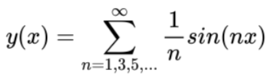
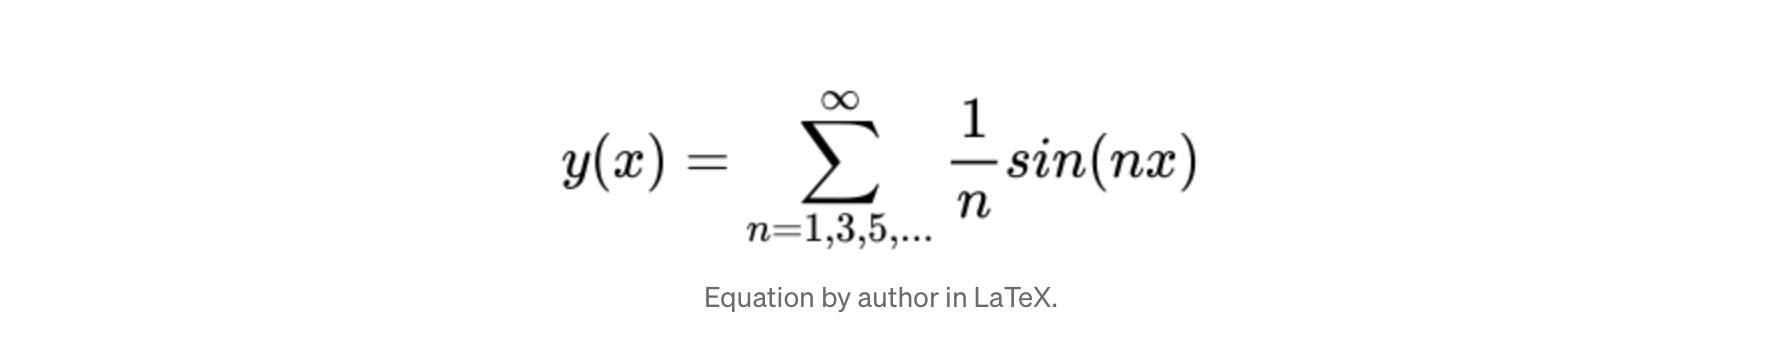

In [2]:
import plotly.graph_objs as go
import numpy as np

x = np.linspace(0, 3 * np.pi, 1000)
y = np.array([np.sin((2*k + 1) * x) / (2*k + 1) for k in range(100)]).sum(axis=0) * (4 / np.pi)

trace = go.Scatter(x=x, y=y, mode='lines', name='Square Wave', line=dict(color='blue'))

layout = go.Layout(
    title='Square Wave',
    xaxis=dict(title='X'),
    yaxis=dict(title='Y', range=[-1.5, 1.5])
)

data = [trace]

fig = go.Figure(data=data, layout=layout)

fig.show()

Điều đáng kinh ngạc về kết quả này là chúng ta đã tạo ra một biểu đồ đường thẳng và sắc nét từ các hàm sine mượt mà. Điều này cho thấy sức mạnh thực sự của Fourier series để xây dựng bất kỳ hàm tuần hoàn nào.


### Lý thuyết


Như chúng ta đã nói ở trên, Fourier series phát biểu rằng bất kỳ hàm tuần hoàn nào cũng có thể được phân tách thành một tổng của các sóng sine và cosine. Về mặt toán học, điều này được viết như sau:


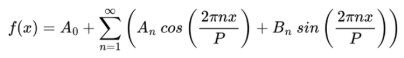
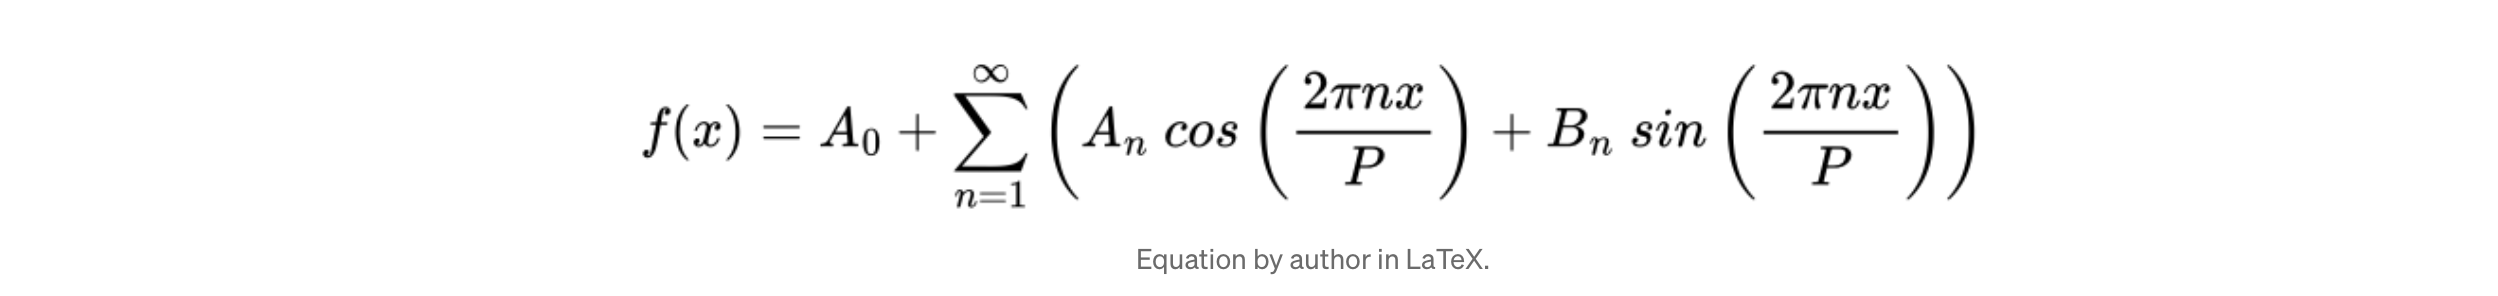

Trong đó:
- A_0: giá trị trung bình của hàm tuần hoàn đã cho
- A_n: coefficients (hệ số) của các thành phần cosine
- B_n: coefficients của các thành phần sine
- n: order (bậc) là frequency (tần số) của sóng sine hoặc cosine, được gọi là 'harmonics' (sóng hài)
- P: period (chu kỳ) của hàm


Period P và order n được biết trước. Tuy nhiên, các coefficients (hệ số) (A_0, A_n, B_n) cần được tính toán để xác định các thành phần sine và cosine nào kết hợp tạo ra hàm tuần hoàn đã cho. May mắn thay, hầu hết các packages khoa học dữ liệu Python đều thực hiện quy trình này cho chúng ta!


### Liên hệ với Forecasting (Dự báo)



Bạn có tự hỏi Fourier series phù hợp với forecasting time series như thế nào không? Chà, hãy nhớ rằng Fourier series xử lý các hàm tuần hoàn và chúng ta thường thấy rằng time series chứa một số cấu trúc tuần hoàn (thường là seasonality - tính mùa vụ). Do đó, chúng ta có thể sử dụng Fourier series để mô hình hóa bất kỳ seasonal pattern (mẫu mùa vụ) phức tạp nào trong dữ liệu time series của chúng ta!

Ưu điểm của việc sử dụng Fourier series để mô hình hóa seasonality là:
- Bất kỳ độ dài season nào
- Mô hình hóa nhiều seasonal patterns
- Độ nhạy của Fourier seasonality có thể được điều chỉnh thông qua order và amplitudes (biên độ) của các thành phần sine và cosine
- Hiệu quả về mặt tính toán khi seasonal periods lớn hơn ~200

Nhiều lợi thế này không thể đạt được với mô hình SARIMA vì nó chỉ chấp nhận seasonality nguyên, một season duy nhất và thường hết bộ nhớ khi seasonal period lớn hơn ~200.

Nhược điểm của việc sử dụng Fourier series để mô hình hóa seasonality là:
- Giả định các seasonal patterns và cycles (chu kỳ) vẫn cố định



## ARIMAX & Exogenous Features



### Trực quan


Đối với các mô hình ARIMA, chúng ta có thể thêm các features (đặc trưng) bên ngoài bổ sung để hỗ trợ trong forecasting (dự báo). Các features này được gọi là exogenous features (đặc trưng ngoại sinh) và làm cho mô hình ARIMA trở thành mô hình ARIMAX. Ví dụ, chúng ta có thể sử dụng lãi suất hiện tại làm exogenous feature khi dự báo giá trị của một ngôi nhà.

Bạn có thể nghĩ mô hình ARIMAX giống như linear regression (hồi quy tuyến tính) thông thường với việc bổ sung các autoregressors và moving-average components (endogenous variables - biến nội sinh). Mẹo ở đây là cho phép Fourier series trở thành một trong những exogenous features này hoặc một explanatory variable (biến giải thích) như thường được mô tả trong linear regression.

Vì chúng ta đang xử lý time series, các exogenous features cần được đánh chỉ số thời gian giống như autoregressors và moving-averages. Chúng cũng cần được biết tại thời điểm forecast. Ví dụ, nếu chúng ta muốn dự báo giá trị của một ngôi nhà vào tháng 5, chúng ta cần biết lãi suất là bao nhiêu vào tháng 5 nếu chúng ta muốn chúng làm exogenous feature.


### Lý thuyết


Về mặt toán học, các exogenous features được thêm vào mô hình ARIMA cổ điển theo cách sau:


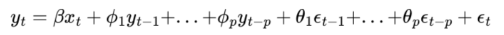
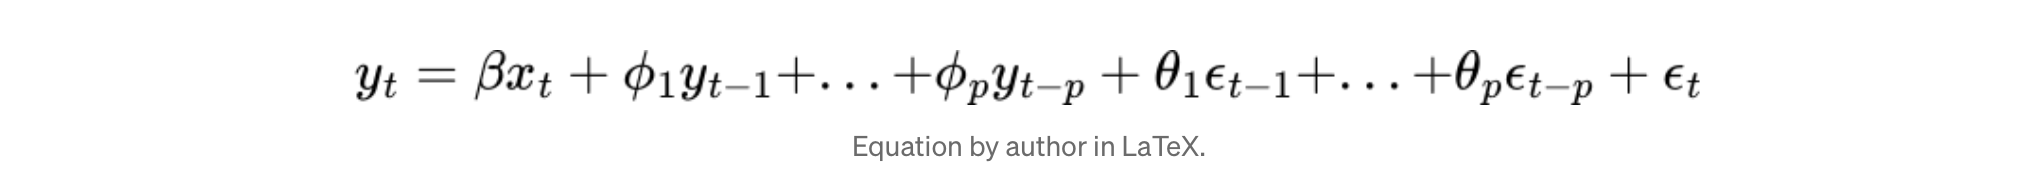

- y: time-series/lags (độ trễ) ở các bước thời gian khác nhau
- x: exogenous feature (đặc trưng ngoại sinh)
- β: coefficient (hệ số) cho exogenous feature
- ϕ: coefficients của các autoregressive components (lags)
- p: số lượng autoregressive components
- ε: forecast error terms (sai số dự báo), các moving-average components
- θ: coefficients của các lagged forecast errors
- q: số lượng lagged error components


### Fourier Series Features



Để thêm Fourier series làm exogenous vào mô hình ARIMA tương đối đơn giản vì các coefficients/amplitudes (hệ số/biên độ), β, được suy ra cho chúng ta và tất cả những gì chúng ta cần cung cấp là các số hạng sine và cosine tương ứng. Trong pseudo-code (mã giả), điều này tương đương với:


In [ ]:
sin(2*pi*frequency*time_index/period)

cos(2*pi*frequency*time_index/period)

Ví dụ, giả sử chúng ta có dữ liệu hàng tháng với seasonality hàng năm và chúng ta muốn các thành phần Fourier cho tháng 5. Trong pseudo-code, điều này sẽ là:


In [ ]:
sin(2*pi*frequency*5/12)

cos(2*pi*frequency*5/12)

Tuy nhiên, chúng ta vẫn có giá trị frequency (tần số) (order - bậc) để suy ra. Điều này thường được tìm thấy bằng cách truyền nhiều orders thành phần sine và cosine khác nhau và để mô hình tìm những cái hữu ích nhất.


### Hướng dẫn Python




In [6]:
# Import các package
import plotly.graph_objects as go
import pandas as pd
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import pmdarima as pm
import numpy as np

# Đọc dữ liệu
data = pd.read_csv('AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])
data['month_num'] = data['Month'].dt.month

# Ổn định variance
data['Passengers_Boxcox'], lam = boxcox(data['#Passengers'])
data.dropna(inplace=True)

# Lấy fourier features
for order in range(1, 10):
    data[f'fourier_sin_order_{order}'] = np.sin(2 * np.pi * order * data['month_num'] / 12)
    data[f'fourier_cos_order_{order}'] = np.cos(2 * np.pi * order * data['month_num'] / 12)

# tên của fourier features
fourier_features = [i for i in list(data) if i.startswith('fourier')]

# Chia train và test
train = data.iloc[:-int(len(data) * 0.2)]
test = data.iloc[-int(len(data) * 0.2):]

# Xây dựng mô hình auto-ARIMA với fourier features
model = pm.auto_arima(train['Passengers_Boxcox'],
                      X=train[fourier_features],
                      seasonal=False,
                      stepwise=True,
                      suppress_warnings=True,
                      max_order=None,
                      information_criterion='aicc',
                      error_action="ignore")

# Lấy các forecasts và áp dụng biến đổi box-cox nghịch đảo
boxcox_forecasts = model.predict(n_periods=len(test), X=test[fourier_features])
forecasts = inv_boxcox(boxcox_forecasts, lam)


def plot_forecasts(forecasts: list[float], title: str) -> None:
    """Hàm để vẽ các forecasts."""
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=train['Month'], y=train['#Passengers'], name='Train'))
    fig.add_trace(go.Scatter(x=test['Month'], y=test['#Passengers'], name='Test'))
    fig.add_trace(go.Scatter(x=test['Month'], y=forecasts, name='Forecast'))
    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                      width=650, title_x=0.5, height=400, xaxis_title='Ngày',
                      yaxis_title='Khối lượng Hành khách')

    return fig.show()


# Vẽ biểu đồ các forecasts
plot_forecasts(forecasts, 'Harmonic Regression')



In [8]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  116
Model:               SARIMAX(1, 1, 0)   Log Likelihood                 131.638
Date:                Mon, 09 Feb 2026   AIC                           -221.276
Time:                        13:09:05   BIC                           -163.633
Sample:                             0   HQIC                          -197.879
                                - 116                                         
Covariance Type:                  opg                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
intercept               0.0277      0.009      3.100      0.002       0.010       0.045
fourier_sin_order_1    -0.1075      0.021     -5.061      0.000      -0.149      -0.066
fourier_cos_order_1    -0.2980      0.021    -14.055      0.000      -0.340      -0.256
fourier_sin_order_2     0.1716      0.012     14.822      0.000       0.149       0.194
fourier_cos_order_2    -0.0553      0.011     -4.961      0.000      -0.077      -0.033
fourier_sin_order_3    -0.0126      0.004     -2.873      0.004      -0.021      -0.004
fourier_cos_order_3     0.0298      0.004      6.904      0.000       0.021       0.038
fourier_sin_order_4     0.0261      0.004      6.686      0.000       0.018       0.034
fourier_cos_order_4     0.0303      0.004      8.023      0.000       0.023       0.038
fourier_sin_order_5     0.0202      0.004      5.535      0.000       0.013       0.027
fourier_cos_order_5     0.0071      0.004      1.867      0.062      -0.000       0.014
fourier_sin_order_6  3.633e-16   1.57e-16      2.314      0.021    5.55e-17    6.71e-16
fourier_cos_order_6     0.0063      0.005      1.203      0.229      -0.004       0.016
fourier_sin_order_7    -0.0233      0.004     -6.378      0.000      -0.030      -0.016
fourier_cos_order_7     0.0071      0.004      1.867      0.062      -0.000       0.014
fourier_sin_order_8    -0.0290      0.004     -7.425      0.000      -0.037      -0.021
fourier_cos_order_8     0.0303      0.004      8.023      0.000       0.023       0.038
fourier_sin_order_9     0.0103      0.004      2.357      0.018       0.002       0.019
fourier_cos_order_9     0.0298      0.004      6.904      0.000       0.021       0.038
ar.L1                  -0.1621      0.095     -1.698      0.089      -0.349       0.025
sigma2                  0.0059      0.001      6.305      0.000       0.004       0.008
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 1.43
Prob(Q):                              0.86   Prob(JB):                         0.49
Heteroskedasticity (H):               0.56   Skew:                            -0.26
Prob(H) (two-sided):                  0.08   Kurtosis:                         2.81
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 4.82e+19. Standard errors may be unstable.
"""

# Tóm tắt


Khi seasonality (tính mùa vụ) của time series của bạn không phải là số nguyên, có nhiều patterns (mẫu), hoặc rất dài (>50 điểm) thì nên sử dụng Fourier series để mô hình hóa thành phần seasonality này. Điều này có thể đạt được bằng cách thêm Fourier series làm exogenous feature (đặc trưng ngoại sinh) vào mô hình ARIMA thông thường để biến nó thành ARIMAX. Các exogenous features này là các covariates (hiệp biến) bên ngoài giúp dự báo time series.
